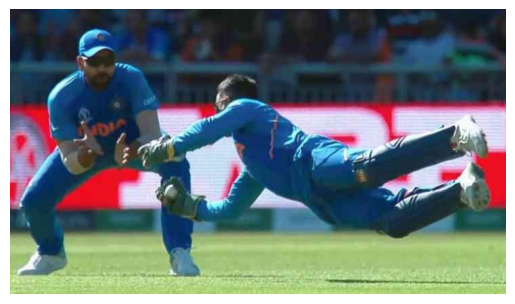

In [17]:
import numpy as np 
import matplotlib.pyplot as plt
import cv2 
image=cv2.imread('dhoni_drive.jpeg')
image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
plt.imshow(image)
plt.axis('off')
plt.show()

In [18]:
pixel_vals = image.reshape((-1,3))
pixel_vals = np.float32(pixel_vals)
print(pixel_vals.shape)
print(pixel_vals[:5])

(305870, 3)
[[34. 32. 43.]
 [34. 32. 43.]
 [34. 32. 43.]
 [34. 32. 43.]
 [34. 32. 43.]]


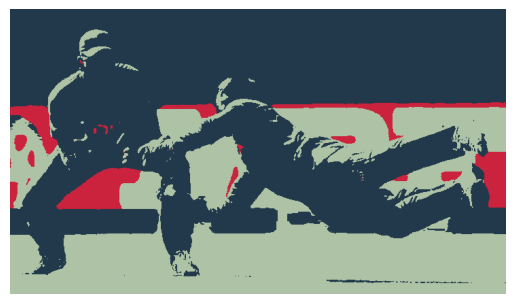

In [19]:
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.85)
k=3 
retval, labels, centers = cv2.kmeans(pixel_vals, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
centers=np.uint8(centers)
segmented_data = centers[labels.flatten()]
segmented_image = segmented_data.reshape((image.shape))
plt.imshow(segmented_image)
plt.axis('off')
plt.show()

unet 

In [20]:
import tensorflow as tf 
def encoder_block(input,num_filters):
    x=tf.keras.layers.Conv2D(num_filters,3,padding='same')(input)
    x=tf.keras.layers.Activation('relu')(x)
    x=tf.keras.layers.Conv2D(num_filters,3,padding='same')(x)
    x=tf.keras.layers.Activation('relu')(x)
    p=tf.keras.layers.MaxPooling2D((2,2))(x)
    return x, p

def decoder_block(input,skip_features,num_filters):
    x=tf.keras.layers.Conv2DTranspose(num_filters,(2,2),strides=2,padding='same')(input)
    x=tf.keras.layers.Concatenate()([x,skip_features])
    x=tf.keras.layers.Conv2D(num_filters,3,padding='same')(x)
    x=tf.keras.layers.Activation('relu')(x)
    x=tf.keras.layers.Conv2D(num_filters,3,padding='same')(x)
    x=tf.keras.layers.Activation('relu')(x)
    return x

In [21]:
def unet_model(input_shape=(256,256,3),num_classes=1):
    inputs=tf.keras.layers.Input(input_shape)
    s1,p1=encoder_block(inputs,64)
    s2,p2=encoder_block(p1,128)
    s3,p3=encoder_block(p2,256)
    s4,p4=encoder_block(p3,512)
    #bottleneck
    b1=tf.keras.layers.Conv2D(1024,3,padding='same')(p4)
    b1=tf.keras.layers.Activation('relu')(b1)
    b1=tf.keras.layers.Conv2D(1024,3,padding='same')(b1)
    b1=tf.keras.layers.Activation('relu')(b1)

    #expansive path
    d1=decoder_block(b1,s4,512)
    d2=decoder_block(d1,s3,256)
    d3=decoder_block(d2,s2,128)
    d4=decoder_block(d3,s1,64)

    outputs=tf.keras.layers.Conv2D(num_classes,1,activation='sigmoid')(d4)
    model=tf.keras.Model(inputs,outputs,name='UNET')
    return model
if __name__=='__main__':
    model=unet_model(input_shape=(576,576,3),num_classes=2)
    model.summary()

Model: "UNET"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 576, 576,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_103 (Conv2D) │ (None, 576, 576,  │      1,792 │ input_layer_8[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_101      │ (None, 576, 576,  │          0 │ conv2d_103[0][0]  │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_104 (Conv2D) │ (None, 576, 576,  │     36,928 │ activation_101[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_102      │ (None, 576, 576,  │          0 │ conv2d_104[0][0]  │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_16    │ (None, 288, 288,  │          0 │ activation_102[0… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_105 (Conv2D) │ (None, 288, 288,  │     73,856 │ max_pooling2d_16… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_103      │ (None, 288, 288,  │          0 │ conv2d_105[0][0]  │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_106 (Conv2D) │ (None, 288, 288,  │    147,584 │ activation_103[0… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_104      │ (None, 288, 288,  │          0 │ conv2d_106[0][0]  │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_17    │ (None, 144, 144,  │          0 │ activation_104[0… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_107 (Conv2D) │ (None, 144, 144,  │    295,168 │ max_pooling2d_17… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_105      │ (None, 144, 144,  │          0 │ conv2d_107[0][0]  │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_108 (Conv2D) │ (None, 144, 144,  │    590,080 │ activation_105[0… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_106      │ (None, 144, 144,  │          0 │ conv2d_108[0][0]  │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_18    │ (None, 72, 72,    │          0 │ activation_106[0… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_109 (Conv2D) │ (None, 72, 72,    │  1,180,160 │ max_pooling2d_18

 Total params: 31,031,810 (118.38 MB)

 Trainable params: 31,031,810 (118.38 MB)

 Non-trainable params: 0 (0.00 B)

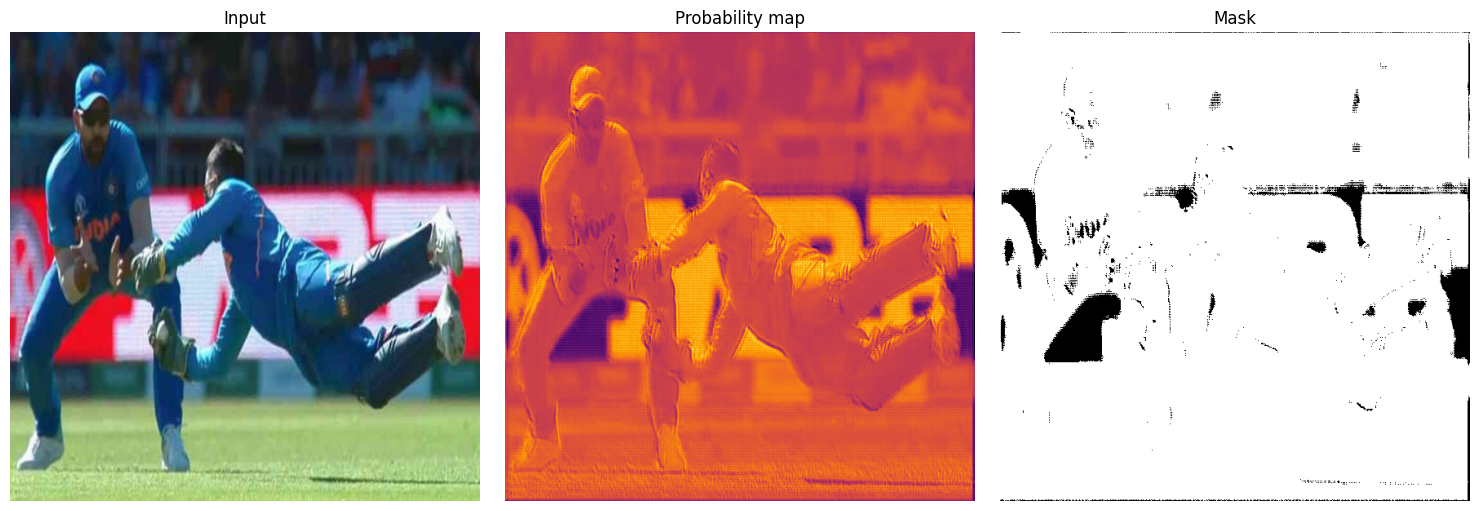

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from PIL import Image

img = Image.open('dhoni_drive.jpeg').convert('RGB').resize((576, 576))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

if 'model' not in globals():
    raise ValueError("Model load/train kora nai. Age trained model run kore abar ei cell chalan.")

predictions = model.predict(img_array, verbose=0)
pred_prob = predictions[0, :, :, -1]
pred_mask = (pred_prob > 0.5).astype(np.uint8) * 255

if pred_mask.min() == pred_mask.max():
    thr = float(pred_prob.mean())
    pred_mask = (pred_prob > thr).astype(np.uint8) * 255
    print(f"Mask uniform chilo. Adaptive threshold use kora holo: {thr:.4f}")

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img)
ax[0].set_title('Input')
ax[1].imshow(pred_prob, cmap='inferno')
ax[1].set_title('Probability map')
ax[2].imshow(pred_mask, cmap='gray')
ax[2].set_title('Mask')
for a in ax:
    a.axis('off')
plt.tight_layout()
plt.show()

with tensorflow plus unet 

## Example 1: Using ctypes (Simplest)

### C++ Code (mylib.cpp)

In [ ]:
# Compile the C++ code to shared library
# Run this in terminal:
# cd cpp_integration
# g++ -shared -fPIC -o mylib.so mylib.cpp

# For macOS:
# g++ -shared -fPIC -o mylib.dylib mylib.cpp

# For Windows:
# g++ -shared -o mylib.dll mylib.cpp

In [24]:
# Python code to use the C++ library (ctypes method)
import ctypes
import numpy as np
import os

# Load the shared library
lib_path = 'cpp_integration/mylib.dylib'  # macOS
# lib_path = 'cpp_integration/mylib.so'  # Linux
# lib_path = 'cpp_integration/mylib.dll'  # Windows

if os.path.exists(lib_path):
    mylib = ctypes.CDLL(lib_path)
    
    # Define function signatures
    mylib.add.argtypes = [ctypes.c_int, ctypes.c_int]
    mylib.add.restype = ctypes.c_int
    
    # Test simple addition
    result = mylib.add(10, 20)
    print(f'✓ C++ add(10, 20) = {result}')
    
    # For array operations
    mylib.array_sum.argtypes = [ctypes.POINTER(ctypes.c_double), ctypes.c_int]
    mylib.array_sum.restype = ctypes.c_double
    
    # Create numpy array and pass to C++
    arr = np.array([1.0, 2.0, 3.0, 4.0, 5.0], dtype=np.float64)
    arr_ptr = arr.ctypes.data_as(ctypes.POINTER(ctypes.c_double))
    sum_result = mylib.array_sum(arr_ptr, len(arr))
    print(f'✓ C++ array_sum([1,2,3,4,5]) = {sum_result}')
    print(f'✓ NumPy verification: {np.sum(arr)}')
else:
    print(f'❌ Library not found at: {lib_path}')
    print('Compile with: cd cpp_integration && g++ -shared -fPIC -o mylib.dylib mylib.cpp')

✓ C++ add(10, 20) = 30
✓ C++ array_sum([1,2,3,4,5]) = 15.0
✓ NumPy verification: 15.0


## Example 2: Using pybind11 (Recommended for Complex Projects)

In [ ]:
# Install pybind11 first
# !pip install pybind11

# Compile the pybind11 module:
# cd cpp_integration
# python setup.py build_ext --inplace

In [ ]:
# Using the pybind11 module in Python
import sys
sys.path.append('cpp_integration')

try:
    import cv_cpp_module
    
    # Test simple function
    result = cv_cpp_module.multiply(5, 7)
    print(f'C++ multiply(5, 7) = {result}')
    
    # Test with numpy array
    import numpy as np
    test_img = np.random.randint(0, 255, (100, 100), dtype=np.uint8)
    blurred = cv_cpp_module.gaussian_blur_cpp(test_img)
    print(f'Blurred image shape: {blurred.shape}')
    
    # Test class
    processor = cv_cpp_module.ImageProcessor(128)
    thresholded = processor.threshold_image(test_img)
    print(f'Thresholded image shape: {thresholded.shape}')
    print(f'Threshold value: {processor.threshold}')
    
except ImportError as e:
    print('Module not compiled yet. Run: cd cpp_integration && python setup.py build_ext --inplace')
    print(f'Error: {e}')

## Example 3: OpenCV with C++ backend (Already integrated!)

In [25]:
# OpenCV Python already uses C++ backend!
# When you use cv2, you're actually calling optimized C++ code

import cv2
import numpy as np
import time

# Create a large image
large_img = np.random.randint(0, 255, (1000, 1000, 3), dtype=np.uint8)

# OpenCV (C++ backend) - FAST
start = time.time()
gray_cv = cv2.cvtColor(large_img, cv2.COLOR_RGB2GRAY)
cv_time = time.time() - start

# Pure Python - SLOW
start = time.time()
gray_py = np.zeros((1000, 1000), dtype=np.uint8)
for i in range(1000):
    for j in range(1000):
        gray_py[i, j] = int(0.299 * large_img[i, j, 0] + 
                            0.587 * large_img[i, j, 1] + 
                            0.114 * large_img[i, j, 2])
py_time = time.time() - start

print(f'OpenCV (C++ backend): {cv_time:.4f} seconds')
print(f'Pure Python loops: {py_time:.4f} seconds')
print(f'Speedup: {py_time/cv_time:.1f}x faster with C++!')

OpenCV (C++ backend): 0.0005 seconds
Pure Python loops: 5.6114 seconds
Speedup: 10264.2x faster with C++!


## Comparison Summary

| Method | Pros | Cons | Best For |
|--------|------|------|----------|
| **ctypes** | • Built-in<br>• No compilation for Python side | • Manual type conversion<br>• Error-prone | Simple C functions |
| **pybind11** | • Modern C++11<br>• Automatic type conversion<br>• NumPy support | • Requires compilation<br>• Learning curve | Complex projects |
| **Cython** | • Python-like syntax<br>• Incremental optimization | • New language to learn | Gradual optimization |
| **OpenCV/TensorFlow** | • Already integrated<br>• Production ready | • Limited to library functions | Using existing libraries |

### When to use C++ in Python projects:
1. **Performance-critical operations** (image processing, numerical computations)
2. **Legacy C++ code integration**
3. **Low-level system operations**
4. **Real-time applications**
5. **Memory-efficient processing**

tensorflow plus unet image detection 

In [26]:
import os 
import tensorflow as tf
import numpy as np
import imageio 
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Conv2DTranspose, Concatenate, Activation, Input,Dropout,Conv2D
from tensorflow.keras import Model


In [34]:
from termcolor import colored
def comparator(learner,instructor):
    if len(learner) != len(instructor):
        raise AssertionError("layer count mismatch")
    for a,b in zip(learner,instructor):
        if tuple(a) != tuple(b):
            print(colored("Test failed",attrs=['bold']))
            raise AssertionError("layer shape mismatch")
    print(colored("Test passed",attrs=['bold']))

def summary(model):
    result=[]
    for layer in model.layers:
        output_shape=getattr(layer.output, 'shape', None)
        params=layer.count_params() if hasattr(layer, 'count_params') else 0
        result.append([layer.__class__.__name__, output_shape, params])
    return result

In [35]:
image_path='/Users/imac/Computer_vision/dhoni_drive.jpeg'
mask_path='/Users/imac/Computer_vision/output.jpg'

In [36]:
import os

valid_ext = ('.jpg', '.jpeg', '.png')

def collect_image_paths(path):
    if os.path.isdir(path):
        return sorted([
            os.path.join(path, f)
            for f in os.listdir(path)
            if f.lower().endswith(valid_ext)
        ])
    if os.path.isfile(path):
        if path.lower().endswith(valid_ext):
            return [path]
        raise ValueError(f'Unsupported file type: {path}')
    raise FileNotFoundError(f'Path not found: {path}')

image_list = collect_image_paths(image_path)
mask_list = collect_image_paths(mask_path)

print(f'image count: {len(image_list)}, mask count: {len(mask_list)}')
if len(image_list) != len(mask_list):
    print('Warning: image/mask count mismatch')

image count: 1, mask count: 1


Available images: 1
Available masks: 1
Image list: ['/Users/imac/Computer_vision/dhoni_drive.jpeg']
Mask list: ['/Users/imac/Computer_vision/output.jpg']


/var/folders/79/qf4s258d1979pqm6v_z63bmc0000gn/T/ipykernel_1704/3373562808.py:12: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img=imageio.imread(image_list[N])
/var/folders/79/qf4s258d1979pqm6v_z63bmc0000gn/T/ipykernel_1704/3373562808.py:13: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  mask=imageio.imread(mask_list[N])


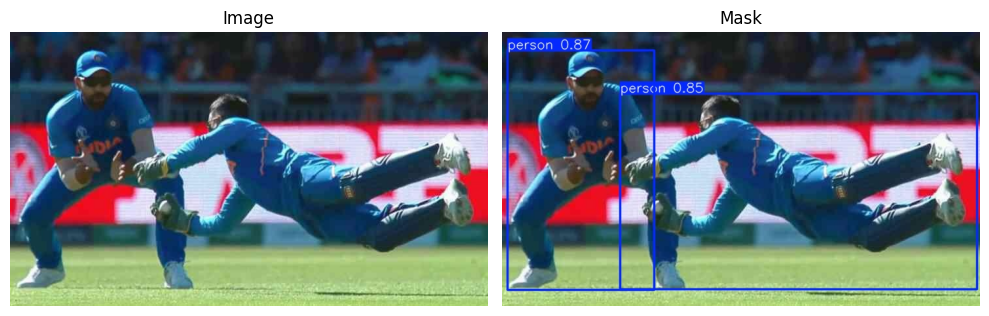

In [ ]:
print(f'Available images: {len(image_list)}')
print(f'Available masks: {len(mask_list)}')
print(f'Image list: {image_list}')
print(f'Mask list: {mask_list}')

# Fix: Use N=0 since you only have 1 image
N = 0  # Changed from 2 to 0
if N >= len(image_list):
    print(f' Error: N={N} but only {len(image_list)} images available')
    N = 0
    
img=imageio.imread(image_list[N])
mask=imageio.imread(mask_list[N])
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img)
ax[0].set_title('Image')
ax[1].imshow(mask)
ax[1].set_title('Mask')
for a in ax:
    a.axis('off')
plt.tight_layout()
plt.show()

create dataset 

In [41]:
image_filenames=tf.constant(image_list)
mask_filenames=tf.constant(mask_list)
dataset=tf.data.Dataset.from_tensor_slices((image_filenames,mask_filenames))

In [57]:
def process_path(image_path,mask_path):
    img=tf.io.read_file(image_path)
    img=tf.image.decode_jpeg(img,channels=3)
    img.set_shape([None, None, 3])
    img=tf.image.convert_image_dtype(img,tf.float32)

    mask=tf.io.read_file(mask_path)
    mask=tf.image.decode_jpeg(mask,channels=3)
    mask.set_shape([None, None, 3])
    mask=tf.math.reduce_max(mask,axis=-1,keepdims=True)
    # CRITICAL: Convert mask to float32 IMMEDIATELY after decode
    mask=tf.cast(mask, tf.float32)
    return img,mask

def preprocess(image,mask):
    # Resize images
    input_image=tf.image.resize(image,(256,256),method='nearest')
    input_mask=tf.image.resize(mask,(256,256),method='nearest')
    
    # Image already normalized in process_path
    
    # Normalize mask to [0, 1] (mask is now float32)
    input_mask = input_mask / 255.0
    
    # Ensure mask is binary (0 or 1)
    input_mask = tf.where(input_mask > 0.5, 1.0, 0.0)
    
    return input_image, input_mask
    
image_ds=dataset.map(process_path,num_parallel_calls=tf.data.AUTOTUNE)
processed_image_ds=image_ds.map(preprocess,num_parallel_calls=tf.data.AUTOTUNE)

U-Net Model 

In [49]:
# Define conv_block and upsampling_block functions
def conv_block(inputs, num_filters, dropout=0.0, max_pooling=True):
    """Convolutional block with 2 Conv layers"""
    conv = Conv2D(num_filters, 3, padding='same', activation='relu')(inputs)
    conv = Conv2D(num_filters, 3, padding='same', activation='relu')(conv)
    
    if dropout > 0:
        conv = Dropout(dropout)(conv)
    
    if max_pooling:
        pool = MaxPooling2D((2, 2))(conv)
        return conv, pool
    else:
        return conv, conv

def upsampling_block(inputs, skip_features, num_filters):
    """Upsampling block with Conv2DTranspose and concatenation"""
    upsample = Conv2DTranspose(num_filters, (2, 2), strides=2, padding='same')(inputs)
    concat = Concatenate()([upsample, skip_features])
    conv = Conv2D(num_filters, 3, padding='same', activation='relu')(concat)
    conv = Conv2D(num_filters, 3, padding='same', activation='relu')(conv)
    return conv

In [52]:
def unet_model(input_shape=(256,256,3),num_classes=1,num_filters=32):
    """U-Net model for image segmentation"""
    inputs=Input(input_shape)
    
    # Encoder path
    c1, p1 = conv_block(inputs, num_filters)
    c2, p2 = conv_block(p1, num_filters*2)
    c3, p3 = conv_block(p2, num_filters*4)
    c4, p4 = conv_block(p3, num_filters*8, dropout=0.3)
    
    # Bottleneck
    c5, _ = conv_block(p4, num_filters*16, dropout=0.3, max_pooling=False)
    
    # Decoder path
    u6 = upsampling_block(c5, c4, num_filters*8)
    u7 = upsampling_block(u6, c3, num_filters*4)
    u8 = upsampling_block(u7, c2, num_filters*2)
    u9 = upsampling_block(u8, c1, num_filters)
    
    # Output layer
    outputs = Conv2D(num_classes, 1, activation='sigmoid' if num_classes==1 else 'softmax')(u9)
    
    return Model(inputs, outputs, name='U-Net')

# Create and compile the model
unet = unet_model(input_shape=(256,256,3), num_classes=1)
unet.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
unet.summary()

Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_13      │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_161 (Conv2D) │ (None, 256, 256,  │        896 │ input_layer_13[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_162 (Conv2D) │ (None, 256, 256,  │      9,248 │ conv2d_161[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_32    │ (None, 128, 128,  │          0 │ conv2d_162[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_163 (Conv2D) │ (None, 128, 128,  │     18,496 │ max_pooling2d_32… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_164 (Conv2D) │ (None, 128, 128,  │     36,928 │ conv2d_163[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_33    │ (None, 64, 64,    │          0 │ conv2d_164[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_165 (Conv2D) │ (None, 64, 64,    │     73,856 │ max_pooling2d_33… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_166 (Conv2D) │ (None, 64, 64,    │    147,584 │ conv2d_165[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_34    │ (None, 32, 32,    │          0 │ conv2d_166[0][0]  │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_167 (Conv2D) │ (None, 32, 32,    │    295,168 │ max_pooling2d_34… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_168 (Conv2D) │ (None, 32, 32,    │    590,080 │ conv2d_167[0][0]  │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 32, 32,    │          0 │ conv2d_168[0][0]  │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_35    │ (None, 16, 16,    │          0 │ dropout_6[0][0]   │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_169 (Conv2D) │ (None, 16, 16,    │  1,180,160 │ max_pooling2d_35… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_170 (Conv2D) │ (None, 16, 16,    │  2,359,808 │ conv2d_169[0][0]  │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 16, 16,    │          0 │ conv2d_170[0][0]

 Total params: 7,760,097 (29.60 MB)

 Trainable params: 7,760,097 (29.60 MB)

 Non-trainable params: 0 (0.00 B)

In [58]:
# COMPLETELY REBUILD dataset WITHOUT cache
print("🔄 Rebuilding dataset from scratch...")
dataset_new = tf.data.Dataset.from_tensor_slices((tf.constant(image_list), tf.constant(mask_list)))
image_ds_new = dataset_new.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
processed_ds_new = image_ds_new.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

# Create training dataset
train_ds_new = processed_ds_new.batch(1).repeat()

# Verify
print("\n✅ Checking processed data:")
for img, mask in train_ds_new.take(1):
    print(f"Image: shape={img.shape}, dtype={img.dtype}, range=[{float(img.numpy().min()):.4f}, {float(img.numpy().max()):.4f}]")
    print(f"Mask:  shape={mask.shape}, dtype={mask.dtype}, range=[{float(mask.numpy().min()):.4f}, {float(mask.numpy().max()):.4f}]")
    
    if mask.dtype == tf.float32 and mask.numpy().max() <= 1.0:
        print("✅ Data is CORRECT!")
    else:
        print(f"❌ ERROR: dtype={mask.dtype}, max={mask.numpy().max()}")

# Fresh model
unet_new = unet_model(input_shape=(256,256,3), num_classes=1)
unet_new.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
print("\n🚀 Training...")
history = unet_new.fit(train_ds_new, epochs=10, steps_per_epoch=1)

🔄 Rebuilding dataset from scratch...

✅ Checking processed data:
Image: shape=(1, 256, 256, 3), dtype=<dtype: 'float32'>, range=[0.0000, 1.0000]
Mask:  shape=(1, 256, 256, 1), dtype=<dtype: 'float32'>, range=[0.0000, 1.0000]
✅ Data is CORRECT!

🚀 Training...
Epoch 1/10


2026-02-14 19:22:42.001409: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.4692 - loss: 0.6795
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 572ms/step - accuracy: 0.4691 - loss: 0.6621
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 577ms/step - accuracy: 0.4691 - loss: 0.6427
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 567ms/step - accuracy: 0.4691 - loss: 0.6232
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 579ms/step - accuracy: 0.4691 - loss: 0.6084
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 566ms/step - accuracy: 0.4691 - loss: 0.5905
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 567ms/step - accuracy: 0.4692 - loss: 0.5695
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 563ms/step - accuracy: 0.4707 - loss: 0.5491
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 580ms/step - accuracy: 0.5254 - loss: 0.5230
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 577ms/step - accuracy: 0.7756 - loss: 0.4951
